In [ ]:
import zipfile
import os

zip_path = "/content/LesionDetection_3.v38-yolov8dinamikcrop.coco-segmentation.zip"
extract_path = "oral_cancer_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted")


Dataset extracted


In [ ]:
for root, dirs, files in os.walk(extract_path):
    print("Folder:", root)
    print("Number of images:", len(files))
    break

Folder: oral_cancer_dataset
Number of images: 2


In [ ]:
import os
import shutil

base_path = "oral_cancer_dataset"

splits = ["train", "valid", "test"]

for split in splits:

    split_path = os.path.join(base_path, split)

    images_folder = os.path.join(split_path, "images")
    masks_old_folder = os.path.join(split_path, "mask")
    masks_new_folder = os.path.join(split_path, "masks")

    # Create new folders
    os.makedirs(images_folder, exist_ok=True)
    os.makedirs(masks_new_folder, exist_ok=True)

    # Move images to images/
    for file in os.listdir(split_path):
        if file.endswith((".jpg", ".png", ".jpeg")):
            src = os.path.join(split_path, file)
            dst = os.path.join(images_folder, file)
            shutil.move(src, dst)

    # Move masks to masks/
    if os.path.exists(masks_old_folder):
        for file in os.listdir(masks_old_folder):
            src = os.path.join(masks_old_folder, file)
            dst = os.path.join(masks_new_folder, file)
            shutil.move(src, dst)

        # remove old mask folder
        os.rmdir(masks_old_folder)

print("✅ Folder structure fixed successfully!")

✅ Folder structure fixed successfully!


In [ ]:
train_images = "/content/oral_cancer_dataset" + "/content/oral_cancer_dataset/train/images"
valid_images = "/content/oral_cancer_dataset" + "/content/oral_cancer_dataset/valid/images"
test_images  = "/content/oral_cancer_dataset" + "/content/oral_cancer_dataset/test/images"

In [ ]:
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q opencv-python matplotlib pycocotools
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

  Preparing metadata (setup.py) ... done


Load SAM model

In [ ]:
import torch
import cv2
import numpy as np
import os
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry["vit_h"](checkpoint="sam_vit_h_4b8939.pth")
sam.to(device)

mask_generator = SamAutomaticMaskGenerator(sam)

print("SAM ready on", device)

SAM ready on cuda


In [ ]:
sam_output = "/content/oral_cancer_dataset" + "/sam_masks"

os.makedirs(sam_output + "/train", exist_ok=True)
os.makedirs(sam_output + "/valid", exist_ok=True)
os.makedirs(sam_output + "/test", exist_ok=True)

In [ ]:
def generate_sam_masks(input_folder, output_folder):

    image_files = os.listdir(input_folder)

    for img_name in image_files:

        if img_name.endswith(('.png','.jpg','.jpeg')):

            img_path = os.path.join(input_folder, img_name)

            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            masks = mask_generator.generate(image)

            if len(masks) == 0:
                continue

            largest_mask = max(masks, key=lambda x: x['area'])

            lesion_mask = largest_mask['segmentation']

            mask_save = (lesion_mask * 255).astype(np.uint8)

            save_name = img_name.split('.')[0] + "_sam_mask.png"

            cv2.imwrite(os.path.join(output_folder, save_name), mask_save)

    print("Done:", output_folder)

In [ ]:
generate_sam_masks("/content/oral_cancer_dataset/train/images", sam_output + "/train")
generate_sam_masks("/content/oral_cancer_dataset/valid/images", sam_output + "/valid")
generate_sam_masks("/content/oral_cancer_dataset/test/images", sam_output + "/test")

Done: /content/oral_cancer_dataset/sam_masks/train
Done: /content/oral_cancer_dataset/sam_masks/valid
Done: /content/oral_cancer_dataset/sam_masks/test


In [ ]:
os.listdir("/content/oral_cancer_dataset")

['test',
 'train',
 'sam_masks',
 'valid',
 'README.dataset.txt',
 'README.roboflow.txt']

Image path: /content/oral_cancer_dataset/train/images/P210_JPG.rf.ef5d6c5f80b888f3d66cd16d2d321100.jpg
Mask path: /content/oral_cancer_dataset/sam_masks/train/P210_JPG_sam_mask.png


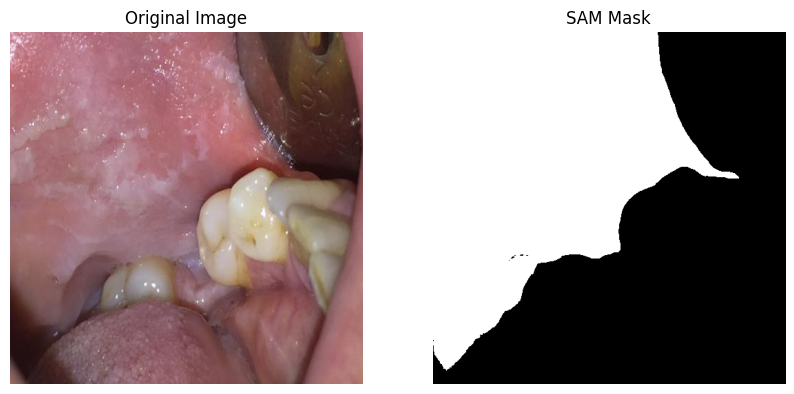

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

dataset_path = "/content/oral_cancer_dataset"

train_images = dataset_path + "/train/images"
sam_masks    = dataset_path + "/sam_masks/train"

# select first image
img_name = os.listdir(train_images)[0]

img_path  = os.path.join(train_images, img_name)
mask_path = os.path.join(sam_masks,
                         img_name.split('.')[0] + "_sam_mask.png")

print("Image path:", img_path)
print("Mask path:", mask_path)

image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path, 0)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("SAM Mask")
plt.axis("off")

plt.show()

In [ ]:
dataset_path = "/content/oral_cancer_dataset"

train_images = dataset_path + "/train/images"
train_masks  = dataset_path + "/train/masks"

sam_masks    = dataset_path + "/sam_masks/train"

valid_images = dataset_path + "/valid/images"
valid_masks  = dataset_path + "/valid/masks"

In [ ]:
!pip install segmentation-models-pytorch
!pip install albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.2 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
import segmentation_models_pytorch as smp

In [ ]:
refined_mask_path = dataset_path + "/refined_masks/train"
os.makedirs(refined_mask_path, exist_ok=True)

image_list = os.listdir(train_masks)

for mask_name in image_list:

    gt_path = os.path.join(train_masks, mask_name)

    sam_name = mask_name.split('.')[0] + "_sam_mask.png"
    sam_path = os.path.join(sam_masks, sam_name)

    if not os.path.exists(sam_path):
        continue

    gt_mask  = cv2.imread(gt_path, 0)
    sam_mask = cv2.imread(sam_path, 0)

    gt_mask  = gt_mask / 255
    sam_mask = sam_mask / 255

    # Combine masks using OR operation
    refined_mask = np.logical_or(gt_mask, sam_mask).astype(np.uint8) * 255

    cv2.imwrite(os.path.join(refined_mask_path, mask_name), refined_mask)

print("Refined masks created")

Refined masks created


In [ ]:
import os
import cv2
import torch
from torch.utils.data import Dataset

def get_sam_mask(image_name, sam_dir):

    base = image_name.split(".rf")[0]

    sam_name = base + "_sam_mask.png"

    sam_path = os.path.join(sam_dir, sam_name)

    if os.path.exists(sam_path):
        return sam_path
    else:
        return None


class OralCancerDataset(Dataset):

    def __init__(self, image_dir, original_mask_dir, sam_mask_dir, size=256):

        self.image_dir = image_dir
        self.original_mask_dir = original_mask_dir
        self.sam_mask_dir = sam_mask_dir
        self.size = size

        self.images = os.listdir(image_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_name = self.images[idx]

        img_path = os.path.join(self.image_dir, img_name)

        original_mask_path = os.path.join(self.original_mask_dir, img_name)

        sam_mask_path = get_sam_mask(img_name, self.sam_mask_dir)

        # Load image
        image = cv2.imread(img_path)
        image = cv2.resize(image, (self.size, self.size))
        image = image / 255.0

        # Load SAM mask if exists
        if sam_mask_path is not None:

            mask = cv2.imread(sam_mask_path, 0)

        else:

            mask = cv2.imread(original_mask_path, 0)

        mask = cv2.resize(mask, (self.size, self.size))
        mask = mask / 255.0

        image = torch.tensor(image).permute(2,0,1).float()
        mask = torch.tensor(mask).unsqueeze(0).float()

        return image, mask

In [ ]:
train_dataset = OralCancerDataset(

    image_dir="/content/oral_cancer_dataset/train/images",

    original_mask_dir="/content/oral_cancer_dataset/train/masks",

    sam_mask_dir="/content/oral_cancer_dataset/sam_masks/train"
)

valid_dataset = OralCancerDataset(

    image_dir="/content/oral_cancer_dataset/valid/images",

    original_mask_dir="/content/oral_cancer_dataset/valid/masks",

    sam_mask_dir="/content/oral_cancer_dataset/sam_masks/valid"
)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

valid_loader = DataLoader(valid_dataset, batch_size=8, shuffle=False)

In [ ]:
import os
import cv2
import numpy as np

dataset_path = "/content/oral_cancer_dataset"

train_images = dataset_path + "/train/images"
gt_masks     = dataset_path + "/train/masks"
sam_masks    = dataset_path + "/sam_masks/train"

refined_mask_path = dataset_path + "/refined_masks/train"

os.makedirs(refined_mask_path, exist_ok=True)

In [ ]:
import os

print("Sample image names:")
print(os.listdir(train_images)[:5])

print("\nSample refined mask names:")
print(os.listdir(refined_mask_path)[:5])

Sample image names:
['P210_JPG.rf.ef5d6c5f80b888f3d66cd16d2d321100.jpg', 'P159_JPG.rf.aa643179742e5282709b38c05c0e72ce.jpg', 'P128_jpg.rf.7e289e4342720a94f46ce7fa91cf6d2b.jpg', 'P120_jpg.rf.c9d51d9cd0f1a04570e5ffee59df7686.jpg', 'P52_jpg.rf.d7dc33abf163fb63bf0332712e7d169a.jpg']

Sample refined mask names:
[]


In [ ]:
print("SAM masks:", len(os.listdir(sam_masks)))

SAM masks: 127


In [ ]:
import torch
import torch.optim as optim
import segmentation_models_pytorch as smp

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.UnetPlusPlus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [ ]:
loss_fn = smp.losses.DiceLoss(mode="binary")

In [ ]:
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

In [ ]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

In [ ]:
def dice_score(pred, target, smooth=1e-6):

    pred = (pred > 0.5).float()

    intersection = (pred * target).sum()

    dice = (2 * intersection + smooth) / (
        pred.sum() + target.sum() + smooth
    )

    return dice.item()


def iou_score(pred, target, smooth=1e-6):

    pred = (pred > 0.5).float()

    intersection = (pred * target).sum()

    union = pred.sum() + target.sum() - intersection

    iou = (intersection + smooth) / (union + smooth)

    return iou.item()


def precision_score(pred, target, smooth=1e-6):

    pred = (pred > 0.5).float()

    TP = (pred * target).sum()

    FP = (pred * (1 - target)).sum()

    precision = (TP + smooth) / (TP + FP + smooth)

    return precision.item()


def recall_score(pred, target, smooth=1e-6):

    pred = (pred > 0.5).float()

    TP = (pred * target).sum()

    FN = ((1 - pred) * target).sum()

    recall = (TP + smooth) / (TP + FN + smooth)

    return recall.item()

In [ ]:
EPOCHS = 100

for epoch in range(EPOCHS):

    model.train()

    train_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        loss = loss_fn(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print("Epoch:", epoch+1, "Train Loss:", train_loss/len(train_loader))

Epoch: 1 Train Loss: 0.2924233394510606
Epoch: 2 Train Loss: 0.24335859102361343
Epoch: 3 Train Loss: 0.19635669974719777
Epoch: 4 Train Loss: 0.17500454187393188
Epoch: 5 Train Loss: 0.1477897377575145
Epoch: 6 Train Loss: 0.13138530885472016
Epoch: 7 Train Loss: 0.12088197469711304
Epoch: 8 Train Loss: 0.10426453983082491
Epoch: 9 Train Loss: 0.10425219816320083
Epoch: 10 Train Loss: 0.09580513309029971
Epoch: 11 Train Loss: 0.0881988756796893
Epoch: 12 Train Loss: 0.07855264228932998
Epoch: 13 Train Loss: 0.07526164896347944
Epoch: 14 Train Loss: 0.07519665886374081
Epoch: 15 Train Loss: 0.07642356437795303
Epoch: 16 Train Loss: 0.06885571690166697
Epoch: 17 Train Loss: 0.0697037752936868
Epoch: 18 Train Loss: 0.059080740984748394
Epoch: 19 Train Loss: 0.05448735110899981
Epoch: 20 Train Loss: 0.050511034095988554
Epoch: 21 Train Loss: 0.055043651777155256
Epoch: 22 Train Loss: 0.05675341451869292
Epoch: 23 Train Loss: 0.0475573785164777
Epoch: 24 Train Loss: 0.04172545320847455
Epo

In [ ]:
model.eval()

valid_loss = 0

dice_total = 0
iou_total = 0
precision_total = 0
recall_total = 0

with torch.no_grad():

    for images, masks in valid_loader:

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        loss = loss_fn(preds, masks)

        valid_loss += loss.item()

        dice_total += dice_score(preds, masks)
        iou_total += iou_score(preds, masks)
        precision_total += precision_score(preds, masks)
        recall_total += recall_score(preds, masks)

n = len(valid_loader)

print("Validation Loss:", valid_loss/n)
print("Dice Score:", dice_total/n)
print("IoU:", iou_total/n)
print("Precision:", precision_total/n)
print("Recall:", recall_total/n)

Validation Loss: 0.06766456365585327
Dice Score: 0.9343186914920807
IoU: 0.8782652020454407
Precision: 0.9529370268185934
Recall: 0.9206350843111674


In [ ]:
scheduler.step(valid_loss)

In [ ]:
torch.save(model.state_dict(),"unetpp_oral_cancer_model.pth")

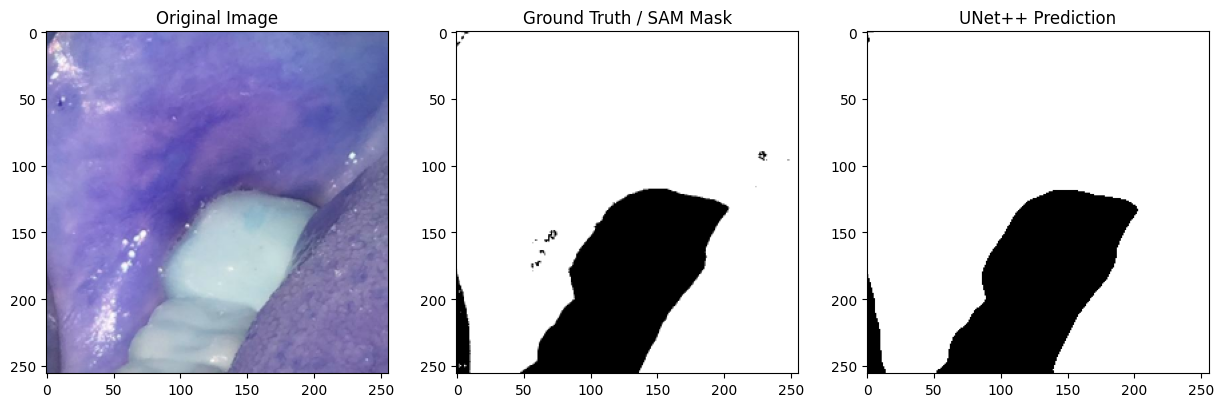

In [ ]:
import matplotlib.pyplot as plt
import cv2

model.eval()

images, masks = next(iter(valid_loader))

images = images.cuda()

with torch.no_grad():

    preds = model(images)

preds = torch.sigmoid(preds)

# select sample index
idx = 0

image = images[idx].cpu().permute(1,2,0).numpy()
true_mask = masks[idx].cpu().squeeze().numpy()
pred_mask = preds[idx].cpu().squeeze().numpy()

pred_mask = (pred_mask > 0.5).astype(np.uint8)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original Image")

plt.subplot(1,3,2)
plt.imshow(true_mask, cmap="gray")
plt.title("Ground Truth / SAM Mask")

plt.subplot(1,3,3)
plt.imshow(pred_mask, cmap="gray")
plt.title("UNet++ Prediction")

plt.show()

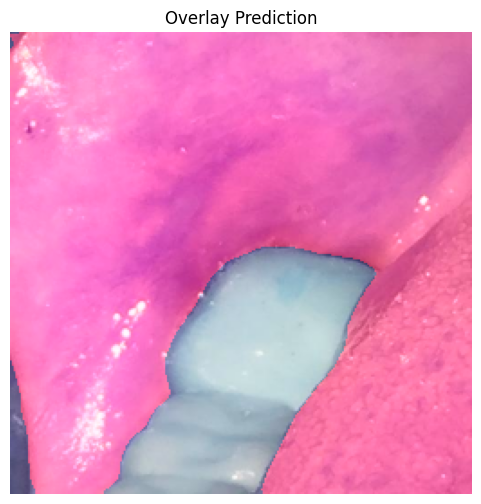

In [ ]:
overlay = image.copy()

overlay[:,:,0] = overlay[:,:,0] + pred_mask * 0.5

plt.figure(figsize=(6,6))

plt.imshow(overlay)

plt.title("Overlay Prediction")

plt.axis("off")

plt.show()

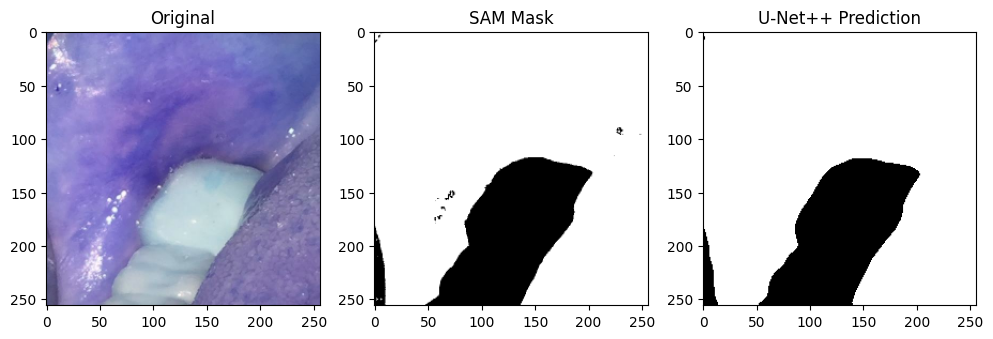

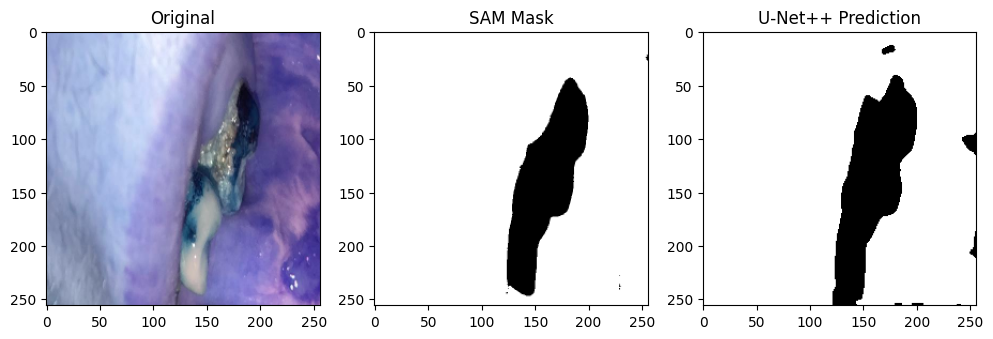

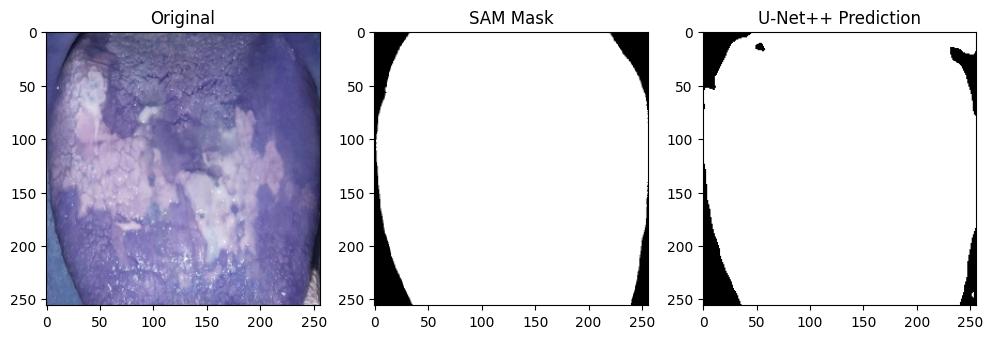

In [ ]:
for i in range(3):

    image = images[i].cpu().permute(1,2,0).numpy()
    true_mask = masks[i].cpu().squeeze().numpy()
    pred_mask = preds[i].cpu().squeeze().numpy()

    pred_mask = (pred_mask > 0.5).astype(np.uint8)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(image)
    plt.title("Original")

    plt.subplot(1,3,2)
    plt.imshow(true_mask,cmap="gray")
    plt.title("SAM Mask")

    plt.subplot(1,3,3)
    plt.imshow(pred_mask,cmap="gray")
    plt.title("U-Net++ Prediction")

    plt.show()

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, auc

model.eval()

dice_total = 0
iou_total = 0
precision_total = 0
recall_total = 0

count = 0

all_probs = []
all_labels = []

with torch.no_grad():

    for images, masks in valid_loader:

        images = images.cuda()
        masks = masks.cuda()

        preds = model(images)
        preds = torch.sigmoid(preds)

        for i in range(len(preds)):

            # Threshold for metric calculation
            pred_bin = (preds[i] > 0.5).float()

            # Convert tensors to CPU numpy arrays for sklearn metrics
            # Explicitly cast to int to ensure binary classification is recognized
            # pred_bin_np = pred_bin.cpu().numpy().astype(int)
            # masks_i_np = masks[i].cpu().numpy().astype(int)

            # The custom dice_score and iou_score functions (from KS6LuaMlzutr) work with torch tensors
            dice_total += dice_score(pred_bin, masks[i])
            iou_total += iou_score(pred_bin, masks[i])

            # Use custom precision_score and recall_score functions with torch tensors
            precision_total += precision_score(pred_bin, masks[i])
            recall_total += recall_score(pred_bin, masks[i])

            count += 1

            # Store probabilities and labels for curves
            all_probs.extend(preds[i].cpu().numpy().flatten())
            all_labels.extend(masks[i].cpu().numpy().flatten().astype(int)) # Cast to int here


print("Dice Score:", dice_total/count)
print("IoU Score:", iou_total/count)
print("Precision:", precision_total/count)
print("Recall:", recall_total/count)


Dice Score: 0.9206133062063262
IoU Score: 0.8815627059964246
Precision: 0.9395370944294819
Recall: 0.9247505151948263


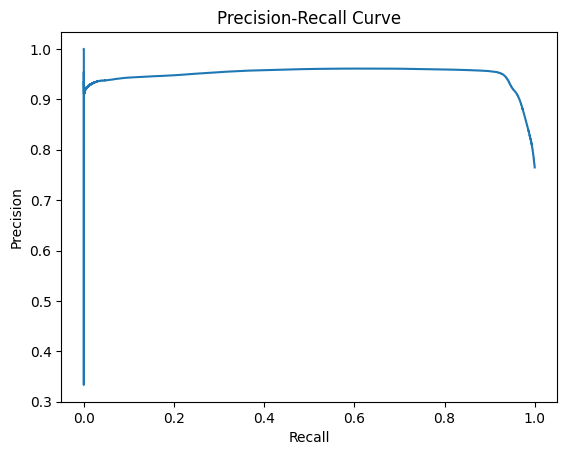

In [ ]:
precision_curve, recall_curve, _ = precision_recall_curve(all_labels, all_probs)

plt.figure()
plt.plot(recall_curve, precision_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

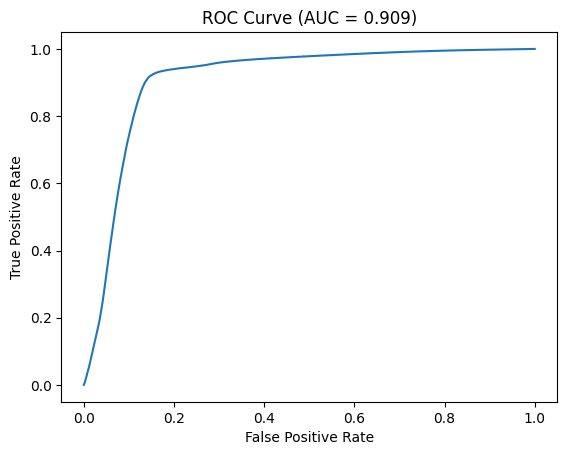

AUC Score: 0.9088154325157973


In [ ]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (AUC = {:.3f})".format(roc_auc))
plt.show()

print("AUC Score:", roc_auc)

prompt sensitivity analysis


In [ ]:
!pip install scikit-learn

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.metrics import jaccard_score

In [ ]:
def dice_score(pred, target):

    pred = pred.flatten()
    target = target.flatten()

    intersection = (pred * target).sum()

    return (2. * intersection) / (pred.sum() + target.sum() + 1e-8)

Function to Add Prompt Perturbation

In [ ]:
def perturb_mask(mask, shift=5):

    mask = mask.astype(np.uint8)

    h, w = mask.shape

    M = np.float32([[1,0,shift],[0,1,shift]])

    shifted = cv2.warpAffine(mask, M, (w,h))

    return shifted

In [ ]:
model.eval()

dice_scores = []
iou_scores = []

with torch.no_grad():

    for images, masks in valid_loader:

        images = images.cuda()
        masks = masks.cuda()

        preds = model(images)
        preds = torch.sigmoid(preds)

        preds = (preds > 0.5).float()

        for i in range(images.shape[0]):

            pred = preds[i].cpu().numpy().squeeze()
            gt = masks[i].cpu().numpy().squeeze()

            # create perturbed prompt
            perturbed = perturb_mask(gt, shift=10)

            dice = dice_score(pred, perturbed)

            iou = jaccard_score(
                perturbed.flatten(),
                pred.flatten()
            )

            dice_scores.append(dice)
            iou_scores.append(iou)

print("Average Dice:", np.mean(dice_scores))
print("Average IoU:", np.mean(iou_scores))

Average Dice: 0.8605020587486267
Average IoU: 0.7779550093477114


/tmp/ipykernel_184/3936868255.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([dice_scores, iou_scores],


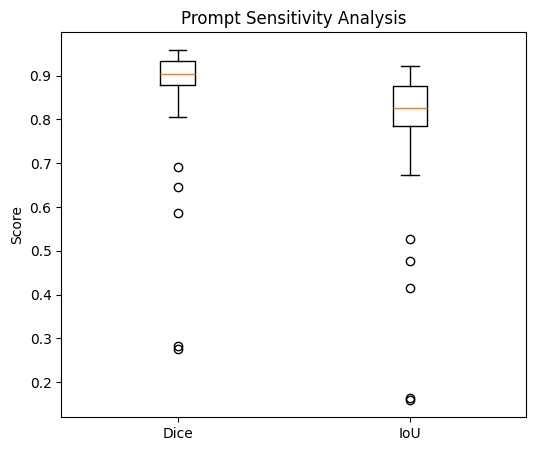

In [ ]:
plt.figure(figsize=(6,5))

plt.boxplot([dice_scores, iou_scores],
            labels=["Dice","IoU"])

plt.title("Prompt Sensitivity Analysis")

plt.ylabel("Score")

plt.show()

ROC CURVE

Result of PSA

Overlay of PSA

OVERALL PERFORMANCE

Comparision ROC & Precision-Recall curve

In [ ]:
from segment_anything import sam_model_registry, SamPredictor
import torch

sam_checkpoint = "/content/sam_vit_h_4b8939.pth"
model_type = "vit_h"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device="cuda")

sam_predictor = SamPredictor(sam)

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

def dice_score(pred, target):
    intersection = np.sum(pred * target)
    return (2 * intersection) / (np.sum(pred) + np.sum(target) + 1e-6)

def iou_score(pred, target):
    intersection = np.sum(pred * target)
    union = np.sum(pred) + np.sum(target) - intersection
    return intersection / (union + 1e-6)

In [ ]:
def generate_prompts_from_mask(pred_mask):

    ys, xs = np.where(pred_mask > 0.5)

    if len(xs) == 0 or len(ys) == 0:
        return None, None

    # Point prompt (center of lesion)
    cx = int(xs.mean())
    cy = int(ys.mean())
    point = np.array([[cx, cy]])
    label = np.array([1])

    # Box prompt
    x1 = xs.min()
    x2 = xs.max()
    y1 = ys.min()
    y2 = ys.max()

    box = np.array([x1, y1, x2, y2])

    return (point, label), box

In [ ]:
def run_sam_prompt(image, prompt_type, pred_mask):

    sam_predictor.set_image(image)

    point_prompt, box_prompt = generate_prompts_from_mask(pred_mask)

    if prompt_type == "point":

        points, labels = point_prompt

        masks, _, _ = sam_predictor.predict(
            point_coords=points,
            point_labels=labels,
            multimask_output=False
        )

        return masks[0]

    elif prompt_type == "box":

        masks, _, _ = sam_predictor.predict(
            box=box_prompt,
            multimask_output=False
        )

        return masks[0]

    elif prompt_type == "mask":

        # Resize predicted mask to SAM input size
        mask_resized = cv2.resize(
            pred_mask.astype(np.float32),
            (256,256)
        )

        # Add batch dimension
        mask_resized = mask_resized[None, :, :]

        masks, _, _ = sam_predictor.predict(
            mask_input=mask_resized,
            multimask_output=False
        )

        return masks[0]

In [ ]:
def evaluate_prompt(prompt_type, data_loader):

    dice_total = 0
    iou_total = 0
    precision_total = 0
    recall_total = 0
    count = 0

    all_probs = [] # Initialize here
    all_labels = [] # Initialize here

    with torch.no_grad():

        for images, masks in data_loader:

            images = images.cuda()
            masks = masks.cuda()

            preds = torch.sigmoid(model(images))

            for i in range(len(images)):

                image_np = images[i].permute(1,2,0).cpu().numpy()
                image_np = (image_np * 255).astype(np.uint8)

                gt_mask = masks[i].cpu().numpy().squeeze()
                pred_mask = preds[i].cpu().numpy().squeeze()

                sam_mask = run_sam_prompt(
                    image_np,
                    prompt_type,
                    pred_mask
                )

                sam_mask_bin = (sam_mask > 0.5).astype(np.uint8)

                y_true = (gt_mask > 0.5).astype(int).flatten()
                y_pred = sam_mask_bin.flatten()

                dice = dice_score(sam_mask_bin, gt_mask)
                iou = iou_score(sam_mask_bin, gt_mask)

                precision = precision_score(y_true, y_pred, zero_division=0)
                recall = recall_score(y_true, y_pred, zero_division=0)

                dice_total += dice
                iou_total += iou
                precision_total += precision
                recall_total += recall

                count += 1

                # Accumulate probabilities and labels for ROC/PR curves
                all_probs.extend(sam_mask.flatten())
                all_labels.extend(y_true)


    return {
        "Dice": dice_total / count,
        "IoU": iou_total / count,
        "Precision": precision_total / count,
        "Recall": recall_total / count,
        "Probs": all_probs,  # Add these to the returned dictionary
        "Labels": all_labels # Add these to the returned dictionary
    }

In [ ]:
prompt_types = ["point","box","mask"]

results = {}

model.eval()

for p in prompt_types:

    print(f"Evaluating {p} prompt")

    metrics = evaluate_prompt(p, valid_loader)

    results[p] = metrics

    print(
        f"Dice: {metrics['Dice']:.4f} | "
        f"IoU: {metrics['IoU']:.4f} | "
        f"Precision: {metrics['Precision']:.4f} | "
        f"Recall: {metrics['Recall']:.4f}"
    )

Evaluating point prompt
Dice: 0.8673 | IoU: 0.8389 | Precision: 0.9431 | Recall: 0.8488
Evaluating box prompt
Dice: 0.9248 | IoU: 0.8988 | Precision: 0.9261 | Recall: 0.9302
Evaluating mask prompt
Dice: 0.0414 | IoU: 0.0256 | Precision: 0.4042 | Recall: 0.0257


In [ ]:
for prompt in results:
    print(f"\nPrompt Type: {prompt}")
    print("Dice Score:", results[prompt]["Dice"])
    print("IoU:", results[prompt]["IoU"])
    print("Precision:", results[prompt]["Precision"])
    print("Recall:", results[prompt]["Recall"])


Prompt Type: point
Dice Score: 0.8673273709119604
IoU: 0.8388982519469792
Precision: 0.9431480231984587
Recall: 0.848772306288765

Prompt Type: box
Dice Score: 0.924758402147723
IoU: 0.8987883349345246
Precision: 0.9261149582741521
Recall: 0.93018677617628

Prompt Type: mask
Dice Score: 0.04141715610705417
IoU: 0.025630553662380956
Precision: 0.40421416552833883
Recall: 0.025659246673358557


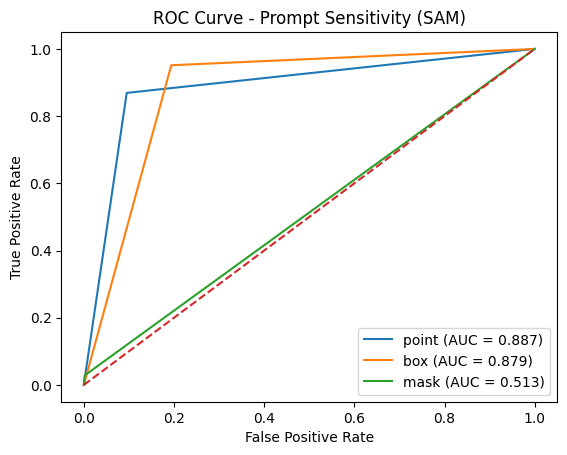

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure()

for prompt in results:
    y_true = results[prompt]["Labels"]
    y_probs = results[prompt]["Probs"]

    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{prompt} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Prompt Sensitivity (SAM)")
plt.legend()
plt.show()

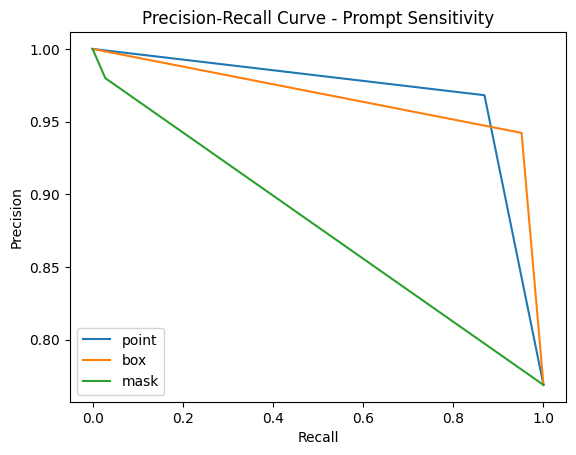

In [ ]:
from sklearn.metrics import precision_recall_curve

plt.figure()

for prompt in results:
    y_true = results[prompt]["Labels"]
    y_probs = results[prompt]["Probs"]

    precision, recall, _ = precision_recall_curve(y_true, y_probs)
    plt.plot(recall, precision, label=prompt)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Prompt Sensitivity")
plt.legend()
plt.show()

Generate U-Net++ Prediction

In [ ]:
model.eval()

images_batch, masks_batch = next(iter(valid_loader))

image_tensor = images_batch[0].unsqueeze(0).cuda()

with torch.no_grad():
    pred = model(image_tensor)
    pred = torch.sigmoid(pred)

unetpp_mask = pred.squeeze().cpu().numpy()
unetpp_mask_bin = (unetpp_mask > 0.5).astype(np.uint8)

image_np = images_batch[0].permute(1,2,0).cpu().numpy()
image_np = (image_np * 255).astype(np.uint8)

Generate SAM Masks for Each Prompt

In [ ]:
sam_point = run_sam_prompt(image_np, "point", unetpp_mask_bin)
sam_box = run_sam_prompt(image_np, "box", unetpp_mask_bin)
sam_mask = run_sam_prompt(image_np, "mask", unetpp_mask_bin)

Store Results

In [ ]:
# Assuming results dictionary from eBMg8IcWXdyG still exists in kernel
# If not, eBMg8IcWXdyG needs to be re-run first.
# For each prompt type, add the example mask to the existing dictionary entry.
results["point"]["example_mask"] = sam_point
results["box"]["example_mask"] = sam_box
results["mask"]["example_mask"] = sam_mask

Visualization

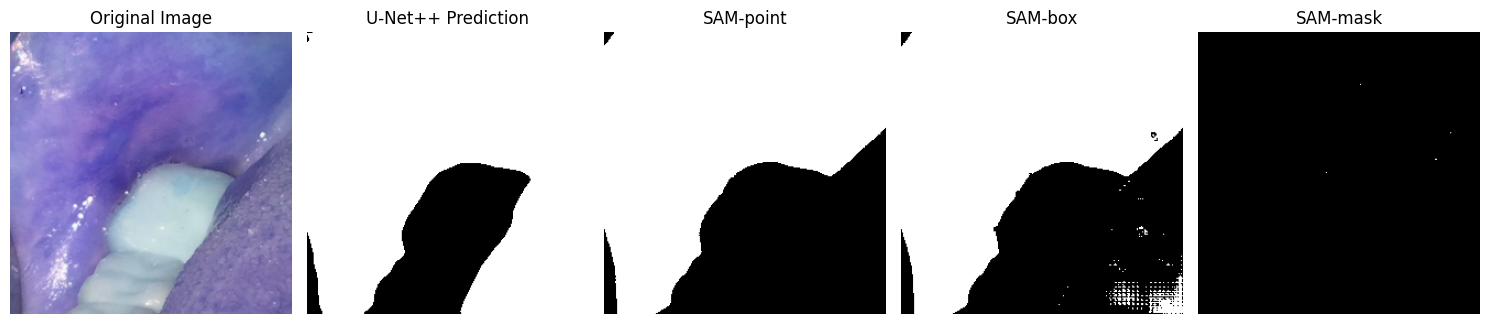

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.subplot(1,5,1)
plt.imshow(image_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,5,2)
plt.imshow(unetpp_mask_bin, cmap="gray")
plt.title("U-Net++ Prediction")
plt.axis("off")

for i, prompt in enumerate(["point","box","mask"]):

    plt.subplot(1,5,i+3)
    plt.imshow(results[prompt]["example_mask"], cmap="gray")
    plt.title(f"SAM-{prompt}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Overlay

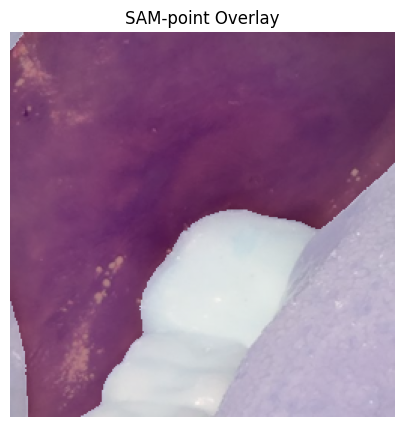

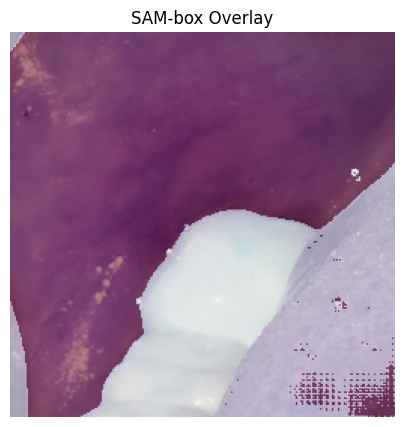

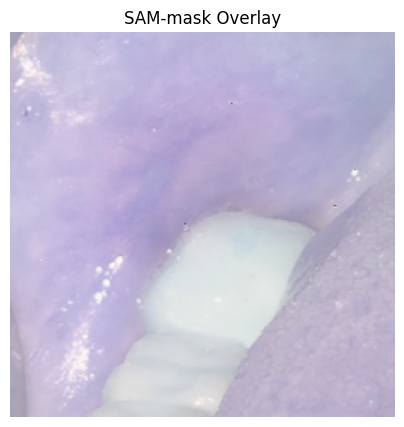

In [ ]:
for i, prompt in enumerate(["point", "box", "mask"]):
    plt.figure(figsize=(5,5))
    plt.imshow(image_np)  # replace with one sample image
    plt.imshow(results[prompt]["example_mask"], alpha=0.5, cmap='Reds')  # semi-transparent overlay
    plt.title(f"SAM-{prompt} Overlay")
    plt.axis('off')
    plt.show()

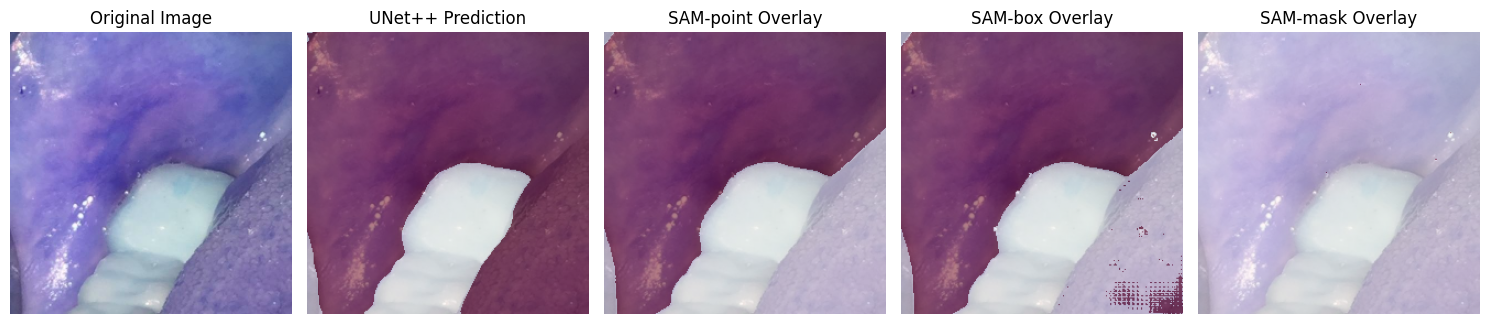

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# Ensure image_np, gt_mask, and results are available from previous cells
# image_np (from 1QcSXM4jCb6M) - (H, W, 3) uint8
# gt_mask (from 1QcSXM4jCb6M) - (H, W) float32 (0.0 or 1.0)
# results (from YsLqlPKqIuCE) - dictionary with SAM metrics and example_mask

# Generate unet_mask_bin and gt_mask_bin
# 1. Regenerate unet_mask for the example image_np
image_tensor_for_unet = torch.tensor(image_np / 255.0).permute(2, 0, 1).float().unsqueeze(0).cuda()
with torch.no_grad():
    unet_pred_tensor = model(image_tensor_for_unet)
    unet_mask = torch.sigmoid(unet_pred_tensor).cpu().squeeze().numpy()
unet_mask_bin = (unet_mask > 0.5).astype(np.uint8)

# 2. Get binary gt_mask
gt_mask_bin = (gt_mask > 0.5).astype(np.uint8)

# 1️⃣ Overlay visualization
plt.figure(figsize=(15,5))

# Original image
plt.subplot(1,5,1)
plt.imshow(image_np)
plt.title("Original Image")
plt.axis("off")

# UNet mask overlay
plt.subplot(1,5,2)
plt.imshow(image_np)
plt.imshow(unet_mask_bin, alpha=0.5, cmap='Reds')
plt.title("UNet++ Prediction")
plt.axis("off")

# SAM predictions overlays
for i, prompt in enumerate(["point", "box", "mask"]):
    plt.subplot(1,5,i+3)
    plt.imshow(image_np)
    plt.imshow(results[prompt]["example_mask"], alpha=0.5, cmap='Reds')
    plt.title(f"SAM-{prompt} Overlay")
    plt.axis("off")

plt.tight_layout()
plt.show()


EXPLANAIBLE  AI


In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 71.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=99dae263879f9ead5ccc4087501e3a94b83ee976b4118bb8d2347c29672d46da
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


IMPORT LIBARIES

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

Put Model in Evaluation Mode

In [ ]:
model.eval()

UnetPlusPlus(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tru

In [ ]:
print(model)

UnetPlusPlus(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tru

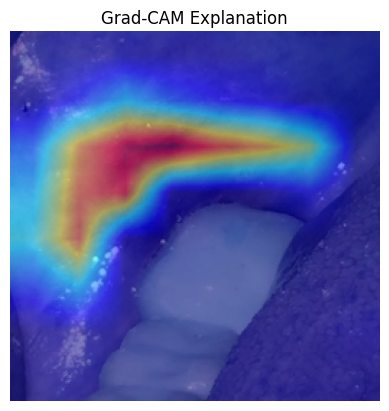

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import SemanticSegmentationTarget # Import for segmentation target

model.eval()

# choose target layer
target_layer = model.encoder.layer4

cam = GradCAM(model=model, target_layers=[target_layer])

images, masks = next(iter(valid_loader))

images = images.cuda()

idx = 0
input_tensor = images[idx].unsqueeze(0)

# Get the model's raw output for the input_tensor
output_from_model = model(input_tensor)
# Convert to probabilities and detach for use as a target mask in numpy format
# Squeeze to remove batch and channel dimensions, as SemanticSegmentationTarget expects (H, W)
target_prediction_mask = torch.sigmoid(output_from_model).detach().cpu().squeeze().numpy()

# Define the target for GradCAM. For a binary segmentation model with classes=1,
# we target category 0 (the only class) and use the predicted mask as the region of interest.
targets = [SemanticSegmentationTarget(category=0, mask=target_prediction_mask)]

# generate heatmap, passing the defined targets
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

# convert image for visualization (normalize to 0-1 range)
image = images[idx].cpu().permute(1,2,0).numpy()
image = (image - image.min())/(image.max()-image.min())

# overlay heatmap
visualization = show_cam_on_image(image, grayscale_cam, use_rgb=True)

plt.imshow(visualization)
plt.title("Grad-CAM Explanation")
plt.axis("off")
plt.show()

VISUALIZATION OF GRADCAM

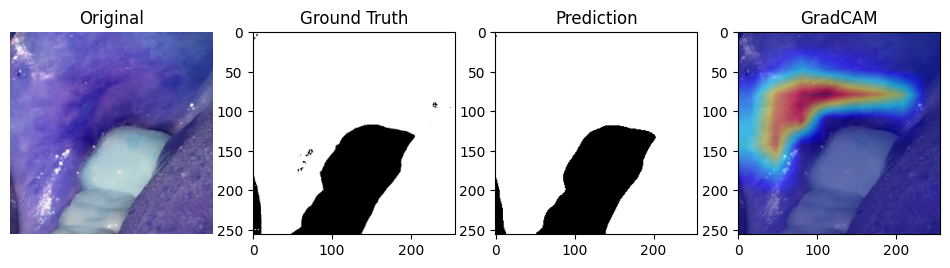

In [ ]:
preds = torch.sigmoid(model(images))
pred_mask = preds[idx].cpu().squeeze().detach().numpy()
pred_mask = (pred_mask > 0.5).astype(np.uint8)

true_mask = masks[idx].cpu().squeeze().detach().numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(true_mask,cmap="gray")
plt.title("Ground Truth")

plt.subplot(1,4,3)
plt.imshow(pred_mask,cmap="gray")
plt.title("Prediction")

plt.subplot(1,4,4)
plt.imshow(visualization)
plt.title("GradCAM")

plt.show()

GRADCAM++

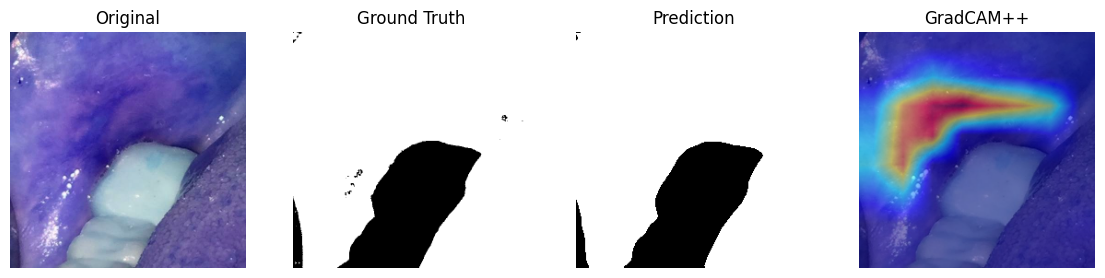

In [ ]:
preds = torch.sigmoid(model(images))

pred_mask = preds[idx].cpu().squeeze().detach().numpy()
pred_mask = (pred_mask > 0.5).astype(np.uint8)

true_mask = masks[idx].cpu().squeeze().detach().numpy()

plt.figure(figsize=(14,4))

plt.subplot(1,4,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(true_mask, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(pred_mask, cmap="gray")
plt.title("Prediction")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(visualization)
plt.title("GradCAM++")
plt.axis("off")

plt.show()

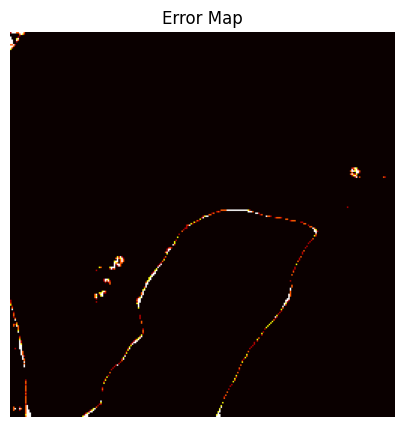

In [ ]:
error_map = np.abs(gt_mask - unet_mask_bin)

plt.figure(figsize=(5,5))
plt.imshow(error_map, cmap="hot")
plt.title("Error Map")
plt.axis("off")
plt.show()

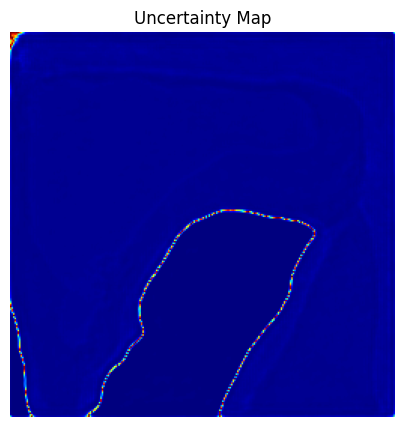

In [ ]:
uncertainty = unet_mask * (1 - unet_mask)

plt.figure(figsize=(5,5))
plt.imshow(uncertainty, cmap="jet")
plt.title("Uncertainty Map")
plt.axis("off")
plt.show()

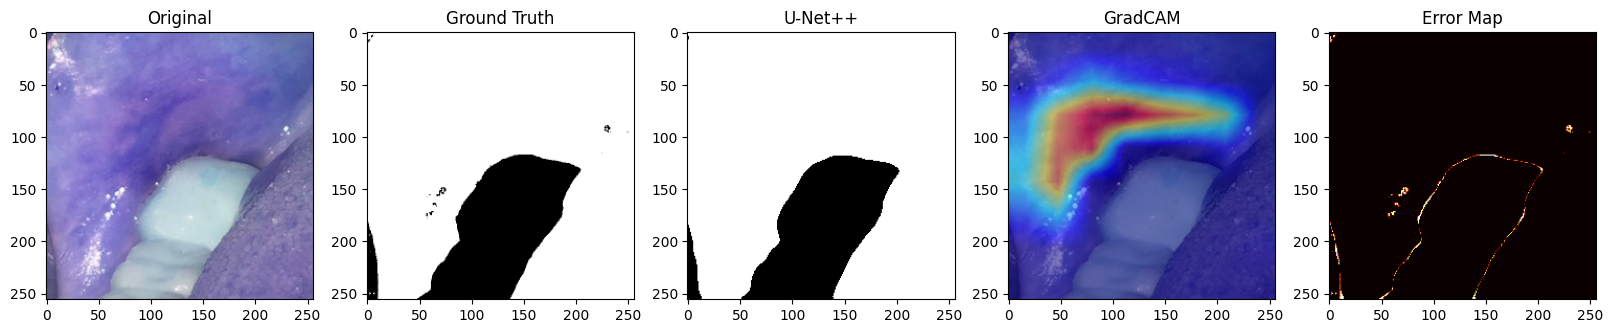

In [ ]:
plt.figure(figsize=(20,4))

plt.subplot(1,5,1)
plt.imshow(image_np)
plt.title("Original")

plt.subplot(1,5,2)
plt.imshow(gt_mask,cmap="gray")
plt.title("Ground Truth")

plt.subplot(1,5,3)
plt.imshow(unet_mask_bin,cmap="gray")
plt.title("U-Net++")

plt.subplot(1,5,4)
plt.imshow(visualization)
plt.title("GradCAM")

plt.subplot(1,5,5)
plt.imshow(error_map,cmap="hot")
plt.title("Error Map")

plt.show()